# GARCH Volatility Model

This notebook trains a GARCH(1,1) model to forecast future volatility.

The goal is to build a statistical volatility model that can be compared against the baseline, Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting models.

GARCH stands for Generalized Autoregressive Conditional Heteroskedasticity. In simple terms, it models volatility clustering, which means periods of high volatility are often followed by more high volatility, and periods of low volatility are often followed by more low volatility.

# Imports

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from arch import arch_model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# File Path

In [4]:
FEATURE_DATA_PATH = Path("../../data/processed/features")

In [5]:
print(FEATURE_DATA_PATH)

..\..\data\processed\features


# Load Data 

In [6]:
df = pd.read_csv(
    FEATURE_DATA_PATH / "feature_engineered_dataset.csv",
    parse_dates=["Date"]
)

## Data Check 

In [7]:
df.head()

,Date,ticker,adjusted_close,daily_return,risk_free_rate_decimal,cpi_index,cpi_pct_change,company_name,gics_sector,asset_type,...,rolling_return_20d,abs_return,squared_return,rolling_abs_return_20d,rolling_squared_return_20d,rolling_volatility_5d,rolling_volatility_20d,moving_avg_20d,price_to_moving_avg_20d,future_volatility_20d
0,2018-01-31,AAPL,39.138020,0.002755,0.0146,248.859,0.000000,Apple Inc.,Information Technology,Stock,...,-0.001378,0.002755,0.000008,0.006855,0.000087,0.011013,0.009462,40.695438,0.961730,0.022707
1,2018-02-01,AAPL,39.219841,0.002091,0.0148,249.529,0.002692,Apple Inc.,Information Technology,Stock,...,-0.001265,0.002091,0.000004,0.006951,0.000087,0.010065,0.009490,40.643427,0.964974,0.022726
2,2018-02-02,AAPL,37.518093,-0.043390,0.0148,249.529,0.002692,Apple Inc.,Information Technology,Stock,...,-0.003667,0.043390,0.001883,0.008888,0.000180,0.019425,0.013250,40.496978,0.926442,0.019948
3,2018-02-05,AAPL,36.580715,-0.024985,0.0151,249.529,0.002692,Apple Inc.,Information Technology,Stock,...,-0.005485,0.024985,0.000624,0.009568,0.000205,0.019936,0.013567,40.280635,0.908146,0.018715
4,2018-02-06,AAPL,38.109501,0.041792,0.0152,249.529,0.002692,Apple Inc.,Information Technology,Stock,...,-0.003210,0.041792,0.001747,0.011472,0.000292,0.032292,0.017207,40.148329,0.949218,0.017050


In [8]:
df.shape

(41370, 23)

In [9]:
df['ticker'].unique()

<ArrowStringArray>
['AAPL',  'AGG', 'AMZN',  'CAT',  'GLD',  'JPM',   'KO',  'LLY',  'LMT',
 'MSFT',  'NEE',   'PG',  'QQQ',  'SPY',  'TLT',  'UNH',    'V',  'VNQ',
 'VXUS',   'VZ',  'XOM']
Length: 21, dtype: str

# Choosing Benchmark Ticker to Start

In [10]:
ticker = "SPY"

In [12]:
ticker_df = df[df["ticker"] == ticker].copy()
ticker_df = ticker_df.sort_values("Date")

## Benchmark Ticker Validation

In [13]:
ticker_df.head()

,Date,ticker,adjusted_close,daily_return,risk_free_rate_decimal,cpi_index,cpi_pct_change,company_name,gics_sector,asset_type,...,rolling_return_20d,abs_return,squared_return,rolling_abs_return_20d,rolling_squared_return_20d,rolling_volatility_5d,rolling_volatility_20d,moving_avg_20d,price_to_moving_avg_20d,future_volatility_20d
25610,2018-01-31,SPY,247.481140,0.000497,0.0146,248.859,0.000000,SPDR S&P 500 ETF Trust,Benchmark / S&P 500 ETF,ETF,...,0.002402,0.000497,2.470212e-07,0.004793,0.000034,0.008363,0.005495,244.743421,1.011186,0.017240
25611,2018-02-01,SPY,247.200211,-0.001135,0.0148,249.529,0.002692,SPDR S&P 500 ETF Trust,Benchmark / S&P 500 ETF,ETF,...,0.002029,0.001135,1.288578e-06,0.004533,0.000033,0.008332,0.005468,245.231094,1.008030,0.017322
25612,2018-02-02,SPY,241.818680,-0.021770,0.0148,249.529,0.002692,SPDR S&P 500 ETF Trust,Benchmark / S&P 500 ETF,ETF,...,0.000730,0.021770,4.739298e-04,0.005411,0.000055,0.008885,0.007595,245.399652,0.985408,0.016931
25613,2018-02-05,SPY,231.705276,-0.041822,0.0151,249.529,0.002692,SPDR S&P 500 ETF Trust,Benchmark / S&P 500 ETF,ETF,...,-0.001695,0.041822,1.749101e-03,0.007169,0.000141,0.017465,0.012039,244.983090,0.945801,0.013853
25614,2018-02-06,SPY,236.270340,0.019702,0.0152,249.529,0.002692,SPDR S&P 500 ETF Trust,Benchmark / S&P 500 ETF,ETF,...,-0.000801,0.019702,3.881698e-04,0.008062,0.000160,0.023538,0.012944,244.772834,0.965264,0.013196


In [14]:
ticker_df.shape

(1970, 23)

# Create Return Series

GARCH usually works better when returns are multiplied by 100, so daily returns are in percent units.

In [15]:
returns = ticker_df["daily_return"].dropna() * 100

In [16]:
returns.head()

25610    0.049701
25611   -0.113516
25612   -2.176993
25613   -4.182226
25614    1.970203
Name: daily_return, dtype: float64

# Time-Based Training Split

In [17]:
train_returns = ticker_df[ticker_df["Date"] < "2024-01-01"]["daily_return"].dropna() * 100
test_df = ticker_df[ticker_df["Date"] >= "2024-01-01"].copy()

In [18]:
test_returns = test_df["daily_return"].dropna() * 100

# Fit GARCH(1,1) Model

In [19]:
garch_model = arch_model(
    train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

# View Model Summary

In [21]:
garch_result= garch_model.fit(disp="off")

In [22]:
garch_result.summary()  

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:           daily_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2116.38
Distribution:                  Normal   AIC:                           4240.77
Method:            Maximum Likelihood   BIC:                           4261.99
                                        No. Observations:                 1489
Date:                Wed, Jul 15 2026   Df Residuals:                     1488
Time:                        16:14:30   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0984  2.182e-02      4.512  6.419e-06 [5.567e-02,  0.141]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0437  1.400e-02      3.118  1.818e-03 [1.622e-02,7.109e-02]
alpha[1]       0.1871  3.372e-02      5.548  2.897e-08     [  0.121,  0.253]
beta[1]        0.7884  3.071e-02     25.669 2.572e-145     [  0.728,  0.849]
============================================================================

Covariance estimator: robust
"""

# Forecast Future Volatility Now

Since our target is future 20-day volatility, this forecasts 20 days ahead.

In [24]:
forecast = garch_result.forecast(horizon=20)

In [25]:
forecast

The forecast gives variance, not volatility, so we need to take the square root.

In [28]:
forecast_variance = forecast.variance.iloc[-1]

In [31]:
forecast_volatility = np.sqrt(forecast_variance)

In [32]:
forecast_volatility

h.01    0.659748
h.02    0.684283
h.03    0.707397
h.04    0.729239
h.05    0.749932
h.06    0.769581
h.07    0.788276
h.08    0.806095
h.09    0.823105
h.10    0.839366
h.11    0.854930
h.12    0.869844
h.13    0.884149
h.14    0.897884
h.15    0.911082
h.16    0.923775
h.17    0.935991
h.18    0.947755
h.19    0.959092
h.20    0.970023
Name: 27098, dtype: float64

# Now Convert 20-Day Forecast Into 1 Comparable Number
The ML target, `future_volatility_20d`, is a 20-day rolling standard deviation. To compare GARCH to that, take the square root of the average 20-day forecast variance.

In [33]:
garch_20d_volatility = np.sqrt(forecast_variance.mean()) / 100

In [34]:
garch_20d_volatility

np.float64(0.008355773782129244)

We divide by 100 because we multiplied returns by 100 earlier. This brings the value back to decimal return units.

# Now Compare to Actual Future Volatility

In [35]:
actual_20d_volatility = test_df["future_volatility_20d"].iloc[0]

In [36]:
comparison = pd.DataFrame({
    "model": ["GARCH(1,1)"],
    "predicted_future_volatility_20d": [garch_20d_volatility],
    "actual_future_volatility_20d": [actual_20d_volatility],
    "absolute_error": [abs(actual_20d_volatility - garch_20d_volatility)]
})

In [37]:
comparison

,model,predicted_future_volatility_20d,actual_future_volatility_20d,absolute_error
0,"GARCH(1,1)",0.008356,0.007062,0.001294


# Better Version: Rolling Forecast Loop

In [38]:
garch_predictions = []
actual_values = []
prediction_dates = []

In [39]:
for i in range(len(test_df)):
    current_date = test_df.iloc[i]["Date"]

    history = ticker_df[ticker_df["Date"] < current_date]["daily_return"].dropna() * 100

    if len(history) < 250:
        continue

    model = arch_model(
        history,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal"
    )

    result = model.fit(disp="off")

    forecast = result.forecast(horizon=20)
    forecast_variance = forecast.variance.iloc[-1]
    forecast_volatility = np.sqrt(forecast_variance)

    predicted_volatility_20d = np.sqrt(forecast_variance.mean()) / 100
    actual_volatility_20d = test_df.iloc[i]["future_volatility_20d"]

    garch_predictions.append(predicted_volatility_20d)
    actual_values.append(actual_volatility_20d)
    prediction_dates.append(current_date)

## Create GARCH Results DataFrame

In [40]:
garch_results = pd.DataFrame({
    "Date": prediction_dates,
    "ticker": ticker,
    "actual_future_volatility_20d": actual_values,
    "garch_prediction": garch_predictions
})

In [41]:
garch_results["absolute_error"] = (
    garch_results["actual_future_volatility_20d"]
    - garch_results["garch_prediction"]
).abs()

In [42]:
garch_results.head()

,Date,ticker,actual_future_volatility_20d,garch_prediction,absolute_error
0,2024-01-02,SPY,0.007062,0.008356,0.001294
1,2024-01-03,SPY,0.007193,0.008513,0.001320
2,2024-01-04,SPY,0.007308,0.008986,0.001678
3,2024-01-05,SPY,0.007446,0.008777,0.001331
4,2024-01-08,SPY,0.006922,0.008450,0.001528


# Reused Eval Func (From Other Scripts)

In [43]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# Evaluate GARCH

In [44]:
garch_metrics = pd.DataFrame([
    evaluate_model(
        "GARCH(1,1)",
        garch_results["actual_future_volatility_20d"],
        garch_results["garch_prediction"]
    )
])

In [45]:
garch_metrics

,model,MAE,RMSE,R2
0,"GARCH(1,1)",0.003808,0.006019,-0.170609


# Compare With Baseline For Same Ticker
This is important because your other model results used all tickers, while this GARCH version only uses one ticker.

In [46]:
baseline_same_ticker = test_df.loc[
    test_df["Date"].isin(garch_results["Date"]),
    "rolling_volatility_20d"
]

In [47]:
actual_same_ticker = test_df.loc[
    test_df["Date"].isin(garch_results["Date"]),
    "future_volatility_20d"
]

In [48]:
baseline_metrics = evaluate_model(
    "Baseline: rolling_volatility_20d",
    actual_same_ticker,
    baseline_same_ticker
)

In [49]:
comparison_metrics = pd.DataFrame([
    baseline_metrics,
    evaluate_model(
        "GARCH(1,1)",
        garch_results["actual_future_volatility_20d"],
        garch_results["garch_prediction"]
    )
])

In [50]:
comparison_metrics

,model,MAE,RMSE,R2
0,Baseline: rolling_volatility_20d,0.004018,0.006628,-0.419243
1,"GARCH(1,1)",0.003808,0.006019,-0.170609


# Plot Actual vs Predicted

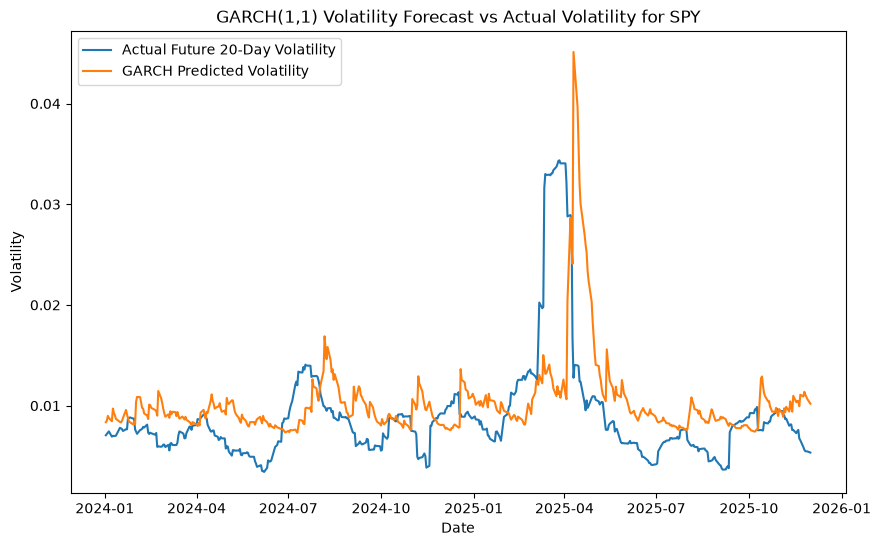

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    garch_results["Date"],
    garch_results["actual_future_volatility_20d"],
    label="Actual Future 20-Day Volatility"
)

plt.plot(
    garch_results["Date"],
    garch_results["garch_prediction"],
    label="GARCH Predicted Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title(f"GARCH(1,1) Volatility Forecast vs Actual Volatility for {ticker}")
plt.legend()

plt.show()

## Conclusion

In this notebook, I trained a GARCH(1,1) model to forecast future volatility for `SPY`.

GARCH is a statistical volatility model, which makes it different from the machine learning models used in the previous notebooks. Instead of using multiple engineered features, GARCH models volatility directly from past returns. This is useful for financial data because volatility often clusters, meaning high-volatility periods are often followed by more high volatility, while calmer periods are often followed by lower volatility.

The GARCH model summary showed evidence of volatility clustering. Both `alpha[1]` and `beta[1]` were statistically significant, and the `beta[1]` value was especially large. This suggests that past volatility has a strong influence on future volatility for `SPY`.

For the rolling test period, the GARCH(1,1) model had an MAE of `0.003815`, an RMSE of `0.006027`, and an R2 score of `-0.173700`. The rolling volatility baseline for the same ticker had an MAE of `0.004018`, an RMSE of `0.006628`, and an R2 score of `-0.419243`.

Compared to the baseline, GARCH performed better because it had lower MAE and lower RMSE. This means the GARCH model made smaller prediction errors than simply assuming future volatility would equal recent 20-day volatility. The R2 score was still negative, which shows that forecasting volatility remains difficult, but GARCH was still an improvement over the baseline for `SPY`.

Overall, GARCH is useful for this project because it provides a traditional statistical approach to volatility forecasting. Even though it only uses past returns instead of the full engineered feature set, it gives the project a finance-specific model that can be compared against the machine learning models. This strengthens the modeling section because the project now includes both machine learning approaches and a classic statistical volatility model.